In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

# 1. Charger les données
df = pd.read_csv('sensor_data.csv')

# 2. Convertir le Timestamp en objet datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 3. Trier par date (au cas où)
df = df.sort_values('Timestamp')

# 4. Gérer les données manquantes (NaN)
# Pour le Deep Learning et la visualisation, l'interpolation linéaire
# est souvent la meilleure méthode pour les capteurs
df_clean = df.copy()
numeric_cols = ['Temperature', 'Humidity', 'Moisture', 'Light', 'Gas']
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')

# Afficher les premières lignes
print("Aperçu des données :")
display(df_clean.head())

Aperçu des données :


,Timestamp,Temperature,Humidity,Moisture,Light,Gas
0,2026-02-11 10:54:32,24.8,47.0,NaN,103.3,5.8
1,2026-02-11 10:54:46,24.8,47.0,NaN,103.3,5.9
2,2026-02-11 10:55:00,24.8,47.0,NaN,103.3,5.8
3,2026-02-11 10:55:16,24.8,47.0,NaN,103.3,5.7
4,2026-02-11 10:55:30,24.8,47.0,NaN,103.3,5.7


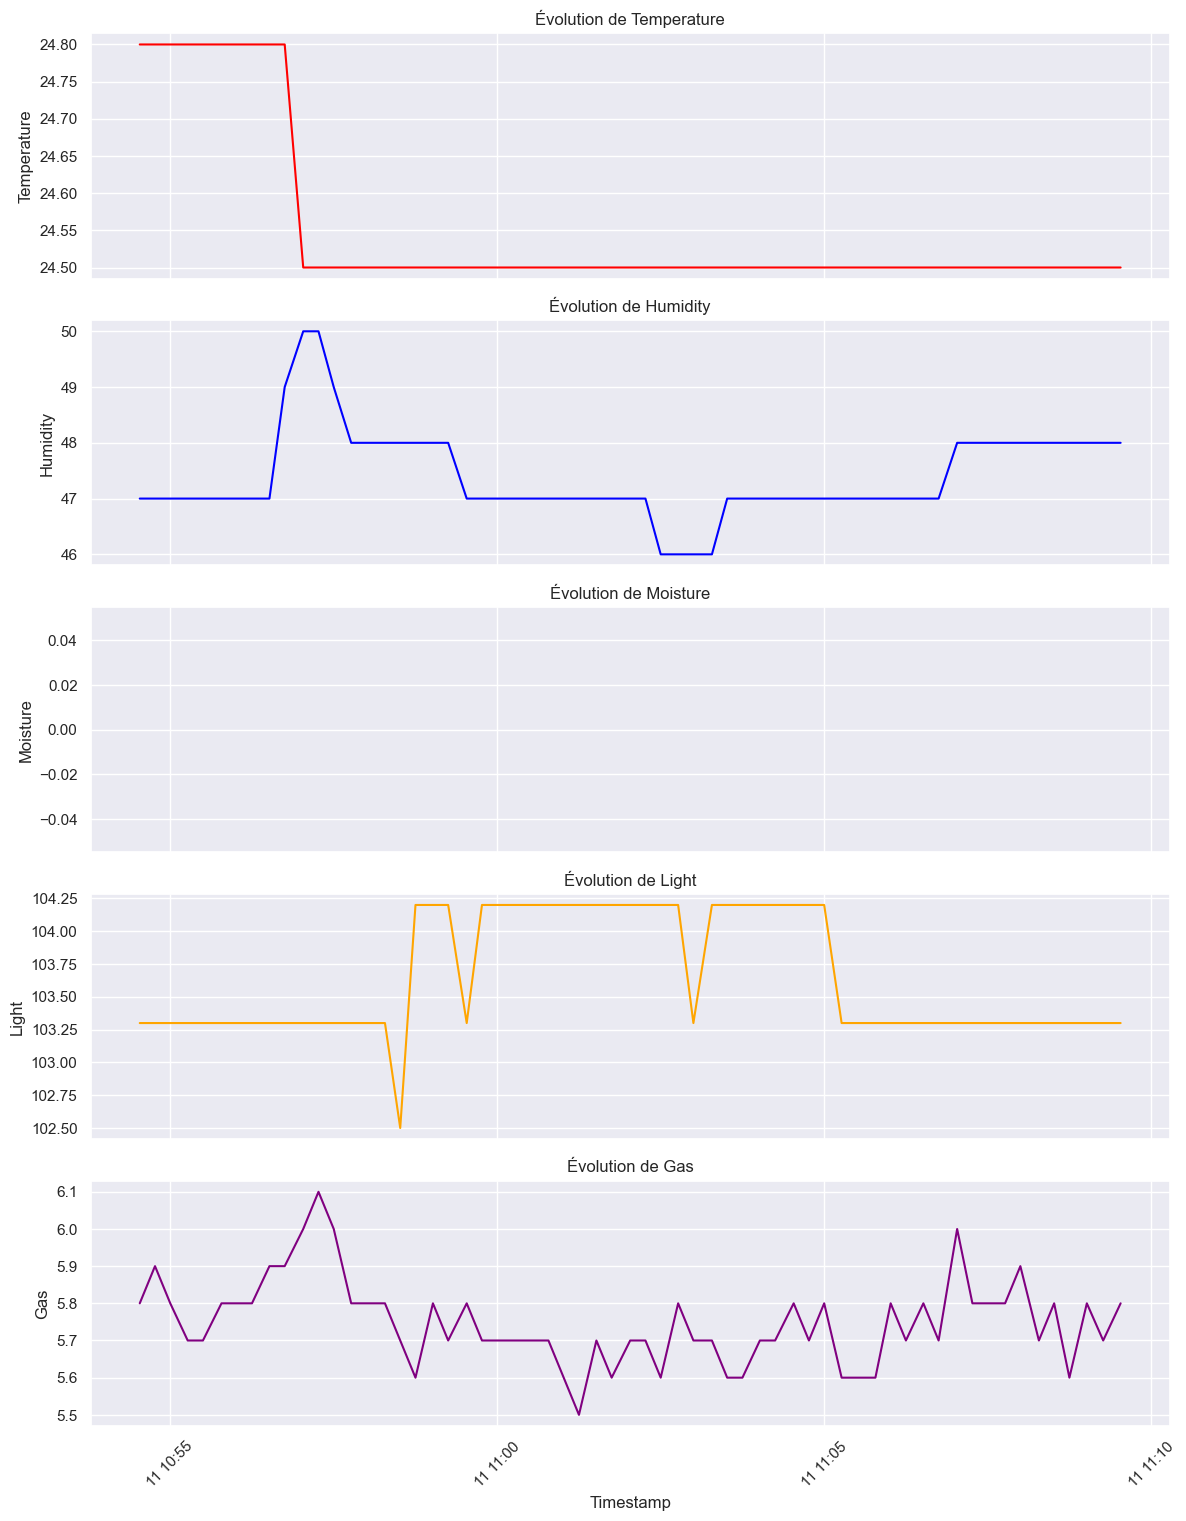

In [3]:
# Configuration du style
sns.set(style="darkgrid")
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 15), sharex=True)

variables = ['Temperature', 'Humidity', 'Moisture', 'Light', 'Gas']
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, var in enumerate(variables):
    sns.lineplot(data=df_clean, x='Timestamp', y=var, ax=axes[i], color=colors[i])
    axes[i].set_title(f'Évolution de {var}', fontsize=12)
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [5]:
# Transformation des données pour Plotly (format long)
df_melted = df_clean.melt(id_vars=['Timestamp'], value_vars=variables,
                          var_name='Capteur', value_name='Valeur')

fig = px.line(df_melted, x='Timestamp', y='Valeur', color='Capteur',
              title='Visualisation Interactive des Capteurs',
              labels={'Timestamp': 'Temps', 'Valeur': 'Mesure'},
              template='plotly_dark')

# Ajout de curseurs pour naviguer dans le temps
fig.update_xaxes(rangeslider_visible=True)

fig.show()